# 02 · Entrenamiento, evaluación y publicación de modelos — Covertype, grupo 2

Metodología:

| Paso | Qué se hace | Buena práctica |
|---|---|---|
| 1 | Cargar `train.covertype` y calcular la **huella del dataset** | Versionado de datos |
| 2 | Guardar un **snapshot** del dataset en MinIO (`datasets/`) | Reproducibilidad: modelo ↔ datos exactos |
| 3 | **Split determinístico por hash** 60/20/20 y verificación de proporciones | Sin *leakage*; métricas comparables entre versiones |
| 4 | Baseline `DummyClassifier` | Piso de comparación honesto |
| 5 | Ajuste de hiperparámetros con **CV estratificada (5 folds)** sobre train, métrica **F1-macro** | Selección sin tocar validación ni test |
| 6 | Comparación en **validación**: gap train-val, balanced accuracy, log loss, recall por clase | Detección de over/underfitting |
| 7 | **Curvas de aprendizaje y de validación** | Diagnóstico de sesgo/varianza |
| 8 | Reajuste con train+val y **evaluación única en test** con **IC 95 % por bootstrap** | Estimación honesta del desempeño |
| 9 | **Importancia por permutación** y análisis de errores | Interpretabilidad |
| 10 | **Publicación versionada** en MinIO + **promoción por reglas explícitas** | Registro de modelos auditable |

> Postgres con el usuario **`covertype_reader` (solo lectura)**; MinIO con el usuario **`trainer`** (escribe en `models` y `datasets`).

## 0. Configuración

In [1]:
import hashlib
import io
import json
import os
import platform
import tempfile
import time
from datetime import datetime
from zoneinfo import ZoneInfo

import boto3
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from botocore.config import Config
from botocore.exceptions import ClientError
from scipy.stats import loguniform
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score,
                             classification_report, f1_score, log_loss, recall_score)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold, learning_curve,
                                     validation_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sqlalchemy import create_engine, text

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

RANDOM_STATE = 42
N_JOBS = 2                      # la VM tiene 4 CPUs y los comparte con otros servicios
TZ = ZoneInfo("America/Bogota")

NUMERICAS = ["elevation", "aspect", "slope", "horizontal_distance_to_hydrology",
             "vertical_distance_to_hydrology", "horizontal_distance_to_roadways",
             "hillshade_9am", "hillshade_noon", "hillshade_3pm", "horizontal_distance_to_fire_points"]
CATEGORICAS = ["wilderness_area", "soil_type"]
FEATURES = NUMERICAS + CATEGORICAS
TARGET = "cover_type"
HASH_COLUMNS = FEATURES + [TARGET]      # mismo orden que el DAG -> mismo row_hash

NOMBRES_CLASE = {0: "Spruce/Fir", 1: "Lodgepole Pine", 2: "Ponderosa Pine", 3: "Cottonwood/Willow",
                 4: "Aspen", 5: "Douglas-fir", 6: "Krummholz"}

# Umbrales explícitos de diagnóstico, selección y promoción
GAP_OK = 0.05                   # gap train-val hasta aquí: sin señal de overfitting
MAX_GAP = 0.10                  # gap train-val por encima de esto: overfitting (no elegible)
MIN_MEJORA_VS_DUMMY = 0.10      # el modelo debe superar al Dummy por al menos esto en F1-macro
MAX_BRECHA_SESGO = 0.20         # F1 train más de esto por debajo del mejor F1 val: alto sesgo (underfitting)

engine = create_engine(os.environ["DATA_DB_URL"])
s3 = boto3.client(
    "s3",
    endpoint_url=os.environ["MINIO_ENDPOINT"],
    aws_access_key_id=os.environ["MINIO_ACCESS_KEY"],
    aws_secret_access_key=os.environ["MINIO_SECRET_KEY"],
    region_name="us-east-1",
    config=Config(signature_version="s3v4"),
)
MODELS_BUCKET = os.environ.get("MODELS_BUCKET", "models")
DATASETS_BUCKET = os.environ.get("DATASETS_BUCKET", "datasets")
PREFIX = "covertype"

VERSIONES = {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
             "numpy": np.__version__, "pandas": pd.__version__, "joblib": joblib.__version__}
print(VERSIONES)

{'python': '3.12.14', 'scikit-learn': '1.9.1', 'numpy': '2.4.6', 'pandas': '3.0.6', 'joblib': '1.6.0'}


## 1. Datos y huella del dataset

El `row_hash` se calcula **igual que en el DAG** (SHA-256 de los 13 valores en el mismo orden), así que identifica cada fila de forma estable.
La **huella** del dataset es el hash del conjunto ordenado de `row_hash`: dos entrenamientos con la misma huella usaron exactamente los mismos datos.

In [2]:
with engine.connect() as conn:
    df = pd.read_sql(text("SELECT * FROM train.covertype"), conn)
    fetch = pd.read_sql(text(
        "SELECT dag_run_id, batch_number FROM raw.fetch_log WHERE status = 'ok' ORDER BY requested_at"), conn)

df["row_hash"] = [
    hashlib.sha256("|".join(str(v) for v in fila).encode("utf-8")).hexdigest()
    for fila in df[HASH_COLUMNS].itertuples(index=False, name=None)
]
assert df.row_hash.is_unique, "Hay filas duplicadas en train.covertype (no debería pasar: el DAG deduplica)"

huella = hashlib.sha256("\n".join(sorted(df.row_hash)).encode()).hexdigest()[:16]
batches = sorted(int(b) for b in fetch.batch_number.unique())
print(f"Filas: {len(df):,} | batches: {batches} | peticiones ok: {len(fetch)}")
print(f"Huella del dataset: {huella}")

Filas: 47,356 | batches: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11] | peticiones ok: 16
Huella del dataset: a6edf31e48e73aaf


### Convención del label

El notebook de preparación del curso convierte el label a **0–6**, pero el ejemplo de la API del profesor muestra un `"1"`.
Se detecta la convención a partir de los datos y se guarda en la metadata del modelo.

In [3]:
etiquetas = sorted(int(c) for c in df[TARGET].unique())
if 0 in etiquetas:
    base_label = 0
elif 7 in etiquetas:
    base_label = 1
else:
    base_label = 0          # ambiguo: se asume la convención 0-6 del notebook de preparación
nombres_clase = {c: NOMBRES_CLASE.get(c - base_label, f"clase {c}") for c in etiquetas}
print(f"Clases presentes: {etiquetas} | convención asumida: {base_label}-{base_label + 6}")
print(nombres_clase)

Clases presentes: [0, 1, 4] | convención asumida: 0-6
{0: 'Spruce/Fir', 1: 'Lodgepole Pine', 4: 'Aspen'}


## 2. Snapshot del dataset en MinIO

Se guarda el dataset exacto en `datasets/covertype/<huella>/`. Si la huella ya existe, **no se vuelve a subir** (idempotente).
Cada modelo apuntará a este snapshot en su metadata.

In [4]:
def s3_existe(bucket, key):
    try:
        s3.head_object(Bucket=bucket, Key=key)
        return True
    except ClientError:
        return False


SNAPSHOT_KEY = f"{PREFIX}/{huella}/train.parquet"
MANIFEST_KEY = f"{PREFIX}/{huella}/manifest.json"

if s3_existe(DATASETS_BUCKET, SNAPSHOT_KEY):
    print(f"Snapshot ya existe: s3://{DATASETS_BUCKET}/{SNAPSHOT_KEY} (no se sube de nuevo)")
else:
    buf = io.BytesIO()
    df[["row_hash"] + HASH_COLUMNS].to_parquet(buf, index=False)
    s3.put_object(Bucket=DATASETS_BUCKET, Key=SNAPSHOT_KEY, Body=buf.getvalue())
    manifest = {
        "fingerprint": huella,
        "rows": int(len(df)),
        "columns": ["row_hash"] + HASH_COLUMNS,
        "batches": batches,
        "dag_run_ids": fetch.dag_run_id.tolist(),
        "class_counts": {str(k): int(v) for k, v in df[TARGET].value_counts().sort_index().items()},
        "created_at": datetime.now(TZ).isoformat(timespec="seconds"),
        "source": "postgres-data: train.covertype",
    }
    s3.put_object(Bucket=DATASETS_BUCKET, Key=MANIFEST_KEY,
                  Body=json.dumps(manifest, indent=2).encode(), ContentType="application/json")
    print(f"Snapshot guardado: s3://{DATASETS_BUCKET}/{SNAPSHOT_KEY} ({buf.tell() / 1e6:.1f} MB)")

Snapshot guardado: s3://datasets/covertype/a6edf31e48e73aaf/train.parquet (3.8 MB)


## 3. Split determinístico por hash (60 / 20 / 20)

Cada fila va a train, validación o test según `int(row_hash[:8], 16) % 100`. Ventajas frente a un split aleatorio:

* una fila cae **siempre** en el mismo conjunto, aunque el dataset crezca con nuevos batches;
* las métricas de distintas versiones del modelo se calculan sobre el mismo test;
* como los datos ya están **deduplicados**, ninguna fila puede estar a la vez en train y test (sin *leakage*).

El hash no estratifica por construcción, así que **se verifica** que cada conjunto conserve las proporciones de clase.

In [5]:
bucket_split = df.row_hash.str[:8].apply(lambda h: int(h, 16) % 100)
df["split"] = np.select([bucket_split < 60, bucket_split < 80], ["train", "val"], default="test")

conteo = pd.crosstab(df[TARGET], df.split)[["train", "val", "test"]]
proporciones = (100 * conteo / conteo.sum()).round(2)
proporciones.columns = [f"% {c}" for c in proporciones.columns]
display(pd.concat([conteo, proporciones], axis=1))

max_desvio = (proporciones.max(axis=1) - proporciones.min(axis=1)).max()
min_por_split = conteo.min().min()
print(f"Tamaños: {conteo.sum().to_dict()}")
print(f"Máxima diferencia de proporción de una clase entre splits: {max_desvio:.2f} puntos")
print(f"Mínimo de ejemplos de una clase en un split: {min_por_split}")
if min_por_split < 20:
    print("AVISO: alguna clase tiene < 20 ejemplos en un split: sus métricas tendrán mucha varianza.")

X = {s: df.loc[df.split == s, FEATURES] for s in ("train", "val", "test")}
y = {s: df.loc[df.split == s, TARGET] for s in ("train", "val", "test")}
CLASES = sorted(y["train"].unique())
MINORITARIA = int(y["train"].value_counts().idxmin())
print(f"Clase minoritaria: {MINORITARIA} ({nombres_clase[MINORITARIA]})")

,train,val,test,% train,% val,% test
cover_type,,,,,,
0,7956,2631,2624,27.96,28.0,27.60
1,20307,6717,6824,71.37,71.5,71.77
4,190,47,60,0.67,0.5,0.63


Tamaños: {'train': 28453, 'val': 9395, 'test': 9508}
Máxima diferencia de proporción de una clase entre splits: 0.40 puntos
Mínimo de ejemplos de una clase en un split: 47
Clase minoritaria: 4 (Aspen)


## 4. Preprocesamiento dentro del Pipeline

Todo el preprocesamiento vive **dentro** del `Pipeline` que se serializa: la API recibe datos crudos
(`"Rawah"`, `"C7745"`) y aplica exactamente las mismas transformaciones aprendidas en train (sin *training/serving skew*).

* Numéricas: imputación por mediana + estandarización (necesaria para la regresión logística; inocua para los árboles).
* Categóricas: imputación por moda + `OneHotEncoder(handle_unknown="ignore")`: una categoría no vista no rompe la predicción.

In [6]:
def preprocesador():
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), NUMERICAS),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAS),
    ])


def pipeline(estimador):
    return Pipeline([("prep", preprocesador()), ("model", estimador)])


def metricas(modelo, Xs, ys):
    pred = modelo.predict(Xs)
    proba = modelo.predict_proba(Xs)
    return {
        "f1_macro": f1_score(ys, pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(ys, pred),
        "accuracy": accuracy_score(ys, pred),
        "log_loss": log_loss(ys, proba, labels=modelo.classes_),
        f"recall_clase_{MINORITARIA}": recall_score(ys, pred, labels=[MINORITARIA], average="macro",
                                                    zero_division=0),
    }

## 5. Baseline: `DummyClassifier`

Siempre predice la clase mayoritaria. Cualquier modelo útil debe superarlo **claramente** en F1-macro.

In [7]:
dummy = pipeline(DummyClassifier(strategy="most_frequent")).fit(X["train"], y["train"])
m_dummy = metricas(dummy, X["val"], y["val"])
print({k: round(v, 4) for k, v in m_dummy.items()})
print(f"-> accuracy de {m_dummy['accuracy']:.1%} sin aprender nada: por eso la métrica principal es F1-macro "
      f"({m_dummy['f1_macro']:.3f} en el baseline).")

{'f1_macro': 0.2779, 'balanced_accuracy': 0.3333, 'accuracy': 0.715, 'log_loss': 10.2741, 'recall_clase_4': 0.0}
-> accuracy de 71.5% sin aprender nada: por eso la métrica principal es F1-macro (0.278 en el baseline).


## 6. Ajuste de hiperparámetros con validación cruzada estratificada

`RandomizedSearchCV` con `StratifiedKFold(5)` **solo sobre train**, optimizando **F1-macro**.
`class_weight` es un hiperparámetro más: la CV decide si compensar el desbalance ayuda, en vez de asumirlo.

**Selección con restricción de gap.** Elegir solo por el mejor F1 de CV premia configuraciones que memorizan train
(sobre todo la clase minoritaria, con pocos ejemplos). Por eso la configuración final se elige con

$$\text{score} = \overline{F1}_{CV} - \max\left(0,\ (\overline{F1}_{train} - \overline{F1}_{CV}) - \text{MAX\_GAP}\right)$$

es decir: gana el mejor F1 de CV, pero cada punto de gap por encima de `MAX_GAP` se descuenta.
Las grillas incluyen opciones de **regularización** (`min_samples_leaf`, `max_depth`, `l2_regularization`) para que existan configuraciones con buen balance sesgo-varianza.

In [8]:
CANDIDATOS = {
    "logreg": (
        LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
        {"model__C": loguniform(1e-2, 1e2),
         "model__class_weight": [None, "balanced"]},
    ),
    "rf": (
        RandomForestClassifier(n_estimators=150, n_jobs=1, random_state=RANDOM_STATE),
        {"model__max_depth": [8, 12, 16, 20],
         "model__min_samples_leaf": [2, 5, 10],
         "model__max_features": ["sqrt", 0.5],
         "model__class_weight": [None, "balanced_subsample"]},
    ),
    "hgb": (
        HistGradientBoostingClassifier(random_state=RANDOM_STATE, early_stopping=True,
                                       validation_fraction=0.1, n_iter_no_change=15),
        {"model__learning_rate": [0.05, 0.1],
         "model__max_leaf_nodes": [15, 31, 63],
         "model__min_samples_leaf": [20, 50, 100],
         "model__l2_regularization": [0.1, 1.0, 5.0],
         "model__max_iter": [300, 600],
         "model__class_weight": [None, "balanced"]},
    ),
}
N_ITER = 10
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def refit_con_gap(cv_results):
    # Índice de la mejor configuración: F1 de CV penalizado por el gap que exceda MAX_GAP
    prueba = np.asarray(cv_results["mean_test_score"])
    entreno = np.asarray(cv_results["mean_train_score"])
    return int(np.argmax(prueba - np.maximum(0, (entreno - prueba) - MAX_GAP)))

busquedas = {}
for nombre, (estimador, grilla) in CANDIDATOS.items():
    t0 = time.time()
    busqueda = RandomizedSearchCV(
        pipeline(estimador), grilla, n_iter=N_ITER, scoring="f1_macro", cv=cv,
        n_jobs=N_JOBS, random_state=RANDOM_STATE, return_train_score=True, refit=refit_con_gap,
    ).fit(X["train"], y["train"])
    busquedas[nombre] = busqueda
    i = busqueda.best_index_
    r = busqueda.cv_results_
    print(f"{nombre:7s} CV F1-macro = {r['mean_test_score'][i]:.4f} ± {r['std_test_score'][i]:.4f} "
          f"(train {r['mean_train_score'][i]:.4f}) | {time.time() - t0:.0f} s")
    print(f"        mejores hiperparámetros: {busqueda.best_params_}")

logreg  CV F1-macro = 0.4362 ± 0.0035 (train 0.4377) | 58 s
        mejores hiperparámetros: {'model__C': np.float64(21.368329072358772), 'model__class_weight': 'balanced'}
rf      CV F1-macro = 0.8736 ± 0.0165 (train 0.9387) | 155 s
        mejores hiperparámetros: {'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 16, 'model__class_weight': 'balanced_subsample'}
hgb     CV F1-macro = 0.9226 ± 0.0084 (train 0.9935) | 156 s
        mejores hiperparámetros: {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 63, 'model__max_iter': 600, 'model__learning_rate': 0.05, 'model__l2_regularization': 0.1, 'model__class_weight': None}


## 7. Comparación en validación y diagnóstico de over/underfitting

| Diagnóstico | Regla | ¿Elegible? |
|---|---|---|
| **underfitting** | F1 val < F1 Dummy + `MIN_MEJORA_VS_DUMMY` | No |
| **underfitting (alto sesgo)** | F1 **train** más de `MAX_BRECHA_SESGO` (0.20) por debajo del mejor F1 de validación: ni siquiera ajusta bien los datos que ve | No |
| **overfitting** | gap train-val > `MAX_GAP` (0.10) | No |
| **ignora clase minoritaria** | recall de la clase minoritaria = 0 | No |
| ok (gap moderado) | `GAP_OK` < gap ≤ `MAX_GAP` | Sí |
| ok | gap ≤ `GAP_OK` (0.05) | Sí |

Además, una desviación alta en CV indica **varianza**: resultado inestable entre folds.

In [9]:
calculadas = {n: (metricas(b.best_estimator_, X["train"], y["train"]),
                  metricas(b.best_estimator_, X["val"], y["val"])) for n, b in busquedas.items()}
mejor_val = max(m_va["f1_macro"] for _, m_va in calculadas.values())

filas = []
for nombre, busqueda in busquedas.items():
    m_tr, m_va = calculadas[nombre]
    i = busqueda.best_index_
    gap = m_tr["f1_macro"] - m_va["f1_macro"]
    if m_va["f1_macro"] < m_dummy["f1_macro"] + MIN_MEJORA_VS_DUMMY:
        diagnostico = "underfitting"
    elif m_tr["f1_macro"] < mejor_val - MAX_BRECHA_SESGO:
        diagnostico = "underfitting (alto sesgo)"
    elif gap > MAX_GAP:
        diagnostico = "overfitting"
    elif m_va[f"recall_clase_{MINORITARIA}"] == 0:
        diagnostico = "ignora clase minoritaria"
    elif gap > GAP_OK:
        diagnostico = "ok (gap moderado)"
    else:
        diagnostico = "ok"
    filas.append({
        "modelo": nombre,
        "cv_f1_macro": busqueda.cv_results_["mean_test_score"][i],
        "cv_std": busqueda.cv_results_["std_test_score"][i],
        "train_f1_macro": m_tr["f1_macro"],
        "val_f1_macro": m_va["f1_macro"],
        "gap_train_val": gap,
        "val_balanced_acc": m_va["balanced_accuracy"],
        "val_log_loss": m_va["log_loss"],
        f"val_recall_{MINORITARIA}": m_va[f"recall_clase_{MINORITARIA}"],
        "val_accuracy": m_va["accuracy"],
        "diagnostico": diagnostico,
    })
filas.append({"modelo": "dummy", "val_f1_macro": m_dummy["f1_macro"],
              "val_balanced_acc": m_dummy["balanced_accuracy"], "val_log_loss": m_dummy["log_loss"],
              f"val_recall_{MINORITARIA}": m_dummy[f"recall_clase_{MINORITARIA}"],
              "val_accuracy": m_dummy["accuracy"], "diagnostico": "baseline"})
comparacion = pd.DataFrame(filas).set_index("modelo")
display(comparacion.round(4))

for nombre in busquedas:
    print(f"\n=== {nombre} (validación) ===")
    print(classification_report(y["val"], busquedas[nombre].predict(X["val"]),
                                target_names=[f"{c} {nombres_clase[c]}" for c in CLASES], digits=3,
                                zero_division=0))

,cv_f1_macro,cv_std,train_f1_macro,val_f1_macro,gap_train_val,val_balanced_acc,val_log_loss,val_recall_4,val_accuracy,diagnostico
modelo,,,,,,,,,,
logreg,0.4362,0.0035,0.4374,0.4295,0.0079,0.7103,0.8551,0.9149,0.5853,underfitting (alto sesgo)
rf,0.8736,0.0165,0.9360,0.8478,0.0882,0.9085,0.1747,0.8511,0.9452,ok (gap moderado)
hgb,0.9226,0.0084,0.9938,0.8882,0.1056,0.8540,0.1015,0.6596,0.9623,overfitting
dummy,NaN,NaN,NaN,0.2779,NaN,0.3333,10.2741,0.0000,0.7150,baseline



=== logreg (validación) ===
                  precision    recall  f1-score   support

    0 Spruce/Fir      0.481     0.664     0.558      2631
1 Lodgepole Pine      0.866     0.552     0.674      6717
         4 Aspen      0.029     0.915     0.056        47

        accuracy                          0.585      9395
       macro avg      0.459     0.710     0.429      9395
    weighted avg      0.754     0.585     0.639      9395


=== rf (validación) ===
                  precision    recall  f1-score   support

    0 Spruce/Fir      0.900     0.918     0.909      2631
1 Lodgepole Pine      0.967     0.957     0.962      6717
         4 Aspen      0.556     0.851     0.672        47

        accuracy                          0.945      9395
       macro avg      0.808     0.908     0.848      9395
    weighted avg      0.947     0.945     0.946      9395


=== hgb (validación) ===
                  precision    recall  f1-score   support

    0 Spruce/Fir      0.946     0.922     0

## 8. Curvas de aprendizaje y de validación

* **Curva de aprendizaje:** ¿mejora el modelo con más datos? Relevante porque los datos llegan por batches.
* **Curva de validación** (profundidad del Random Forest): ¿dónde empieza a sobreajustar al aumentar la complejidad?

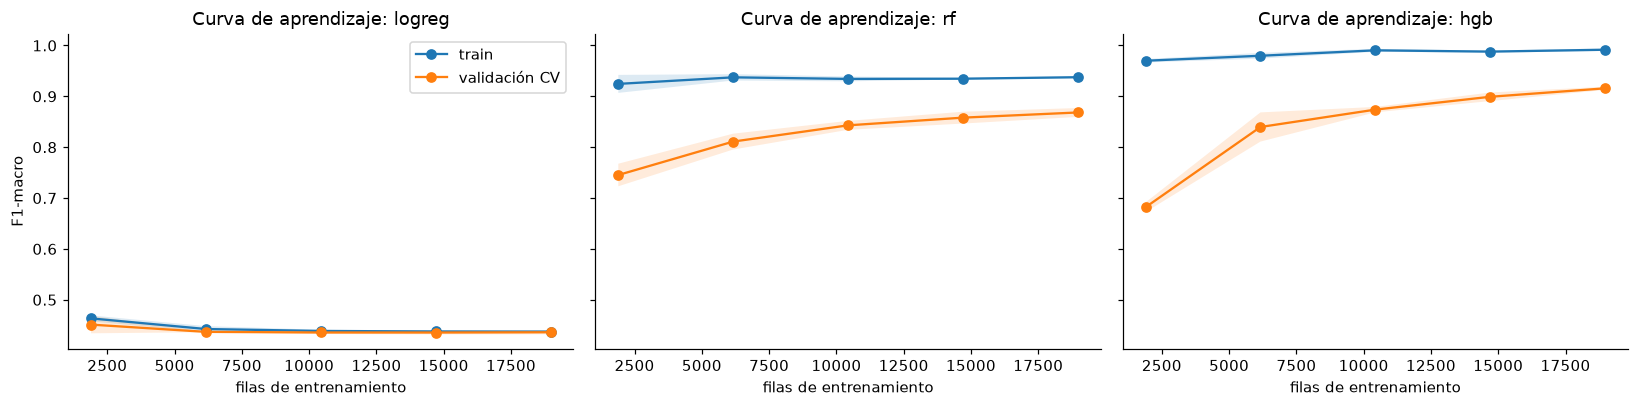

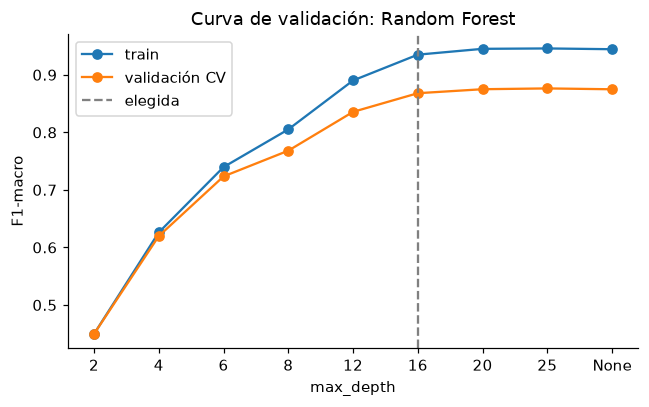

In [10]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, len(busquedas), figsize=(5 * len(busquedas), 3.8), sharey=True)
for ax, (nombre, busqueda) in zip(np.atleast_1d(axes), busquedas.items()):
    tamanos, tr, va = learning_curve(busqueda.best_estimator_, X["train"], y["train"], cv=cv3,
                                     scoring="f1_macro", train_sizes=np.linspace(0.1, 1.0, 5),
                                     n_jobs=N_JOBS, shuffle=True, random_state=RANDOM_STATE)
    for datos, etiqueta in ((tr, "train"), (va, "validación CV")):
        ax.plot(tamanos, datos.mean(axis=1), marker="o", label=etiqueta)
        ax.fill_between(tamanos, datos.mean(axis=1) - datos.std(axis=1),
                        datos.mean(axis=1) + datos.std(axis=1), alpha=0.15)
    ax.set_title(f"Curva de aprendizaje: {nombre}")
    ax.set_xlabel("filas de entrenamiento")
axes[0].set_ylabel("F1-macro")
axes[0].legend()
plt.tight_layout()
plt.show()

profundidades = [2, 4, 6, 8, 12, 16, 20, 25, None]   # incluye todas las opciones de la grilla
params_rf = {k: v for k, v in busquedas["rf"].best_params_.items() if k != "model__max_depth"}
rf_base = pipeline(RandomForestClassifier(n_estimators=100, n_jobs=1, random_state=RANDOM_STATE)).set_params(**params_rf)
tr, va = validation_curve(rf_base, X["train"], y["train"], param_name="model__max_depth",
                          param_range=profundidades, cv=cv3, scoring="f1_macro", n_jobs=N_JOBS)
etiquetas_x = [str(p) for p in profundidades]
plt.figure(figsize=(6, 3.8))
plt.plot(etiquetas_x, tr.mean(axis=1), marker="o", label="train")
plt.plot(etiquetas_x, va.mean(axis=1), marker="o", label="validación CV")
plt.axvline(etiquetas_x.index(str(busquedas["rf"].best_params_["model__max_depth"])), ls="--", c="gray",
            label="elegida")
plt.xlabel("max_depth")
plt.ylabel("F1-macro")
plt.title("Curva de validación: Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Selección del modelo

Regla: **mayor F1-macro en validación** entre los modelos elegibles (diagnóstico `ok`). El test **todavía no se ha usado**.

In [11]:
elegibles = comparacion[comparacion.diagnostico.str.startswith("ok")]
if elegibles.empty:
    print("Ningún modelo cumple los criterios: se elige el de mayor F1 de validación, pero NO se promoverá.")
    elegibles = comparacion.drop(index="dummy")
MEJOR = elegibles.val_f1_macro.idxmax()
print(f"Modelo seleccionado: {MEJOR}")
display(comparacion.loc[[MEJOR, "dummy"]].round(4))

Modelo seleccionado: rf


,cv_f1_macro,cv_std,train_f1_macro,val_f1_macro,gap_train_val,val_balanced_acc,val_log_loss,val_recall_4,val_accuracy,diagnostico
modelo,,,,,,,,,,
rf,0.8736,0.0165,0.936,0.8478,0.0882,0.9085,0.1747,0.8511,0.9452,ok (gap moderado)
dummy,NaN,NaN,NaN,0.2779,NaN,0.3333,10.2741,0.0000,0.7150,baseline


## 10. Modelos finales: reajuste con train + validación y evaluación única en test

Los tres candidatos se reajustan con **train + validación** (más datos) usando sus mejores hiperparámetros.
El test se evalúa **una sola vez**. Con pocos ejemplos de la clase minoritaria, se reporta un
**intervalo de confianza del 95 % por bootstrap** del F1-macro.

logreg  TEST F1-macro = 0.4308  IC95 [0.4221, 0.4402] | balanced acc 0.7327 | recall clase 4 1.000
rf      TEST F1-macro = 0.8913  IC95 [0.8641, 0.9152] | balanced acc 0.9486 | recall clase 4 0.950
hgb     TEST F1-macro = 0.9200  IC95 [0.8933, 0.9427] | balanced acc 0.8949 | recall clase 4 0.767
dummy   TEST F1-macro = 0.2786


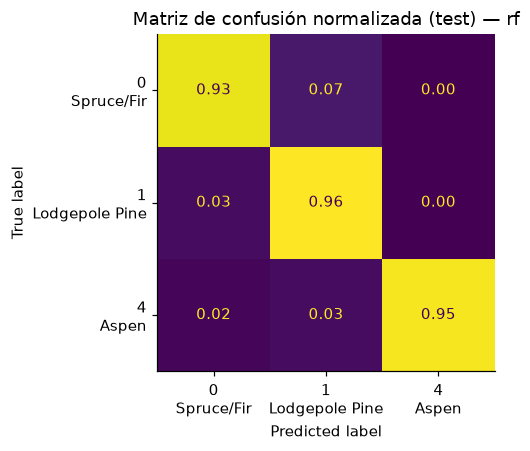

In [12]:
X_trval = pd.concat([X["train"], X["val"]])
y_trval = pd.concat([y["train"], y["val"]])
rng = np.random.default_rng(RANDOM_STATE)


def ic_bootstrap_f1(y_true, y_pred, n=1000):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    idx = rng.integers(0, len(y_true), size=(n, len(y_true)))
    valores = [f1_score(y_true[i], y_pred[i], average="macro") for i in idx]
    return float(np.percentile(valores, 2.5)), float(np.percentile(valores, 97.5))


finales, resultados_test = {}, {}
for nombre, busqueda in busquedas.items():
    modelo = pipeline(CANDIDATOS[nombre][0]).set_params(**busqueda.best_params_).fit(X_trval, y_trval)
    finales[nombre] = modelo
    pred = modelo.predict(X["test"])
    m_te = metricas(modelo, X["test"], y["test"])
    m_te["f1_macro_ic95"] = ic_bootstrap_f1(y["test"], pred)
    resultados_test[nombre] = m_te
    lo, hi = m_te["f1_macro_ic95"]
    print(f"{nombre:7s} TEST F1-macro = {m_te['f1_macro']:.4f}  IC95 [{lo:.4f}, {hi:.4f}] | "
          f"balanced acc {m_te['balanced_accuracy']:.4f} | recall clase {MINORITARIA} "
          f"{m_te[f'recall_clase_{MINORITARIA}']:.3f}")

m_dummy_test = metricas(dummy, X["test"], y["test"])
print(f"dummy   TEST F1-macro = {m_dummy_test['f1_macro']:.4f}")

fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay.from_estimator(finales[MEJOR], X["test"], y["test"], normalize="true", ax=ax,
                                      display_labels=[f"{c}\n{nombres_clase[c]}" for c in CLASES],
                                      values_format=".2f", colorbar=False)
ax.set_title(f"Matriz de confusión normalizada (test) — {MEJOR}")
plt.tight_layout()
plt.show()

## 11. Interpretabilidad: importancia por permutación

Mide cuánto cae el F1-macro de validación al **desordenar** cada variable original (sobre el modelo ajustado solo con train).
A diferencia de la importancia por impureza de los árboles, no está sesgada hacia variables con muchos valores distintos.

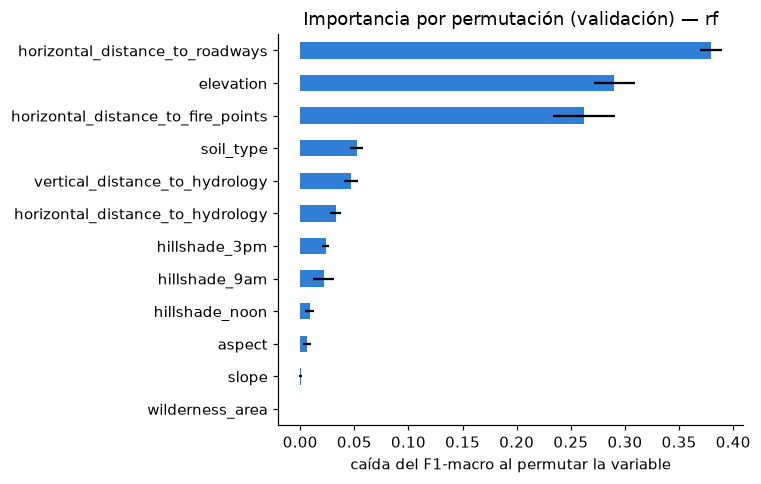

Errores sobre la clase minoritaria (4) en validación: 7 de 47 -> se confunden con: {0: 4, 1: 3}


In [13]:
imp = permutation_importance(busquedas[MEJOR].best_estimator_, X["val"], y["val"], scoring="f1_macro",
                             n_repeats=5, random_state=RANDOM_STATE, n_jobs=N_JOBS)
importancias = pd.DataFrame({"importancia": imp.importances_mean, "std": imp.importances_std},
                            index=FEATURES).sort_values("importancia")
ax = importancias.importancia.plot.barh(xerr=importancias["std"], figsize=(7, 4.5), color="#2f7ed8")
ax.set_xlabel("caída del F1-macro al permutar la variable")
ax.set_title(f"Importancia por permutación (validación) — {MEJOR}")
plt.tight_layout()
plt.show()

errores = X["val"].assign(real=y["val"].values, pred=busquedas[MEJOR].predict(X["val"]))
min_err = errores[(errores.real == MINORITARIA) & (errores.pred != MINORITARIA)]
print(f"Errores sobre la clase minoritaria ({MINORITARIA}) en validación: {len(min_err)} de "
      f"{(errores.real == MINORITARIA).sum()} -> se confunden con: {min_err.pred.value_counts().to_dict()}")

## 12. Publicación versionada en MinIO

```
models/covertype/
├── registry.json                       ← catálogo de versiones + alias "production"
└── <algoritmo>_<AAAAMMDD-HHMMSS>/
    ├── model.joblib                    ← Pipeline completo (preprocesamiento + modelo)
    └── metadata.json                   ← ficha del modelo (model card)
```

**Entrenar y promover son pasos separados**: `publicar_version()` nunca cambia el modelo en producción.

In [14]:
REGISTRY_KEY = f"{PREFIX}/registry.json"


def leer_registry():
    try:
        return json.loads(s3.get_object(Bucket=MODELS_BUCKET, Key=REGISTRY_KEY)["Body"].read())
    except ClientError:
        return {"production": None, "models": {}, "history": []}


def escribir_registry(reg):
    reg["updated_at"] = datetime.now(TZ).isoformat(timespec="seconds")
    s3.put_object(Bucket=MODELS_BUCKET, Key=REGISTRY_KEY, Body=json.dumps(reg, indent=2).encode(),
                  ContentType="application/json")


def latencia_ms_por_fila(modelo, Xs, n=1000):
    muestra = Xs.sample(min(n, len(Xs)), random_state=RANDOM_STATE)
    t0 = time.perf_counter()
    modelo.predict_proba(muestra)
    return 1000 * (time.perf_counter() - t0) / len(muestra)


def publicar_version(nombre, modelo):
    version = f"{nombre}_{datetime.now(TZ):%Y%m%d-%H%M%S}"
    carpeta = f"{PREFIX}/{version}"
    if s3_existe(MODELS_BUCKET, f"{carpeta}/model.joblib"):
        raise RuntimeError(f"La versión {version} ya existe: no se sobrescribe")

    with tempfile.NamedTemporaryFile(suffix=".joblib") as tmp:
        joblib.dump(modelo, tmp.name, compress=3)
        tamano = os.path.getsize(tmp.name)
        s3.upload_file(tmp.name, MODELS_BUCKET, f"{carpeta}/model.joblib")

    fila = comparacion.loc[nombre]
    onehot = modelo.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
    metadata = {
        "version": version,
        "algorithm": type(modelo.named_steps["model"]).__name__,
        "created_at": datetime.now(TZ).isoformat(timespec="seconds"),
        "features": {"numeric": NUMERICAS, "categorical": CATEGORICAS, "order": FEATURES},
        "target": TARGET,
        "classes": [int(c) for c in modelo.classes_],
        "class_names": {str(c): nombres_clase[c] for c in modelo.classes_},
        "label_convention": f"{base_label}-{base_label + 6}",
        "categories_seen": {col: [str(v) for v in cats] for col, cats in zip(CATEGORICAS, onehot.categories_)},
        "hyperparameters": {k.replace("model__", ""): (v if isinstance(v, (int, float, str, type(None))) else str(v))
                            for k, v in busquedas[nombre].best_params_.items()},
        "metrics": {
            "cv_f1_macro_mean": round(float(fila.cv_f1_macro), 4),
            "cv_f1_macro_std": round(float(fila.cv_std), 4),
            "train_f1_macro": round(float(fila.train_f1_macro), 4),
            "val_f1_macro": round(float(fila.val_f1_macro), 4),
            "gap_train_val": round(float(fila.gap_train_val), 4),
            "val_balanced_accuracy": round(float(fila.val_balanced_acc), 4),
            "val_log_loss": round(float(fila.val_log_loss), 4),
            "test": {k: ([round(x, 4) for x in v] if isinstance(v, tuple) else round(float(v), 4))
                     for k, v in resultados_test[nombre].items()},
            "dummy_val_f1_macro": round(float(m_dummy["f1_macro"]), 4),
        },
        "diagnosis": fila.diagnostico,
        "dataset": {
            "fingerprint": huella,
            "snapshot": f"s3://{DATASETS_BUCKET}/{SNAPSHOT_KEY}",
            "rows": int(len(df)),
            "batches": batches,
            "split_rule": "int(row_hash[:8], 16) % 100: <60 train, <80 val, resto test",
            "trained_on": "train + val",
            "split_sizes": {s: int(len(X[s])) for s in X},
        },
        "deployment": {"artifact_bytes": tamano,
                       "latency_ms_per_row": round(latencia_ms_por_fila(modelo, X["test"]), 4)},
        "environment": VERSIONES,
        "random_state": RANDOM_STATE,
        "intended_use": "Clasificar el tipo de cobertura forestal de una celda de 30x30 m a partir de variables cartográficas.",
        "limitations": (f"Entrenado solo con las zonas {sorted(df.wilderness_area.unique().tolist())} y las clases "
                        f"{[int(c) for c in modelo.classes_]}. No predice clases no vistas; zonas o suelos no vistos "
                        "se ignoran en el one-hot y degradan la predicción. Split aleatorio por hash: sin validación "
                        "espacial (celdas vecinas están correlacionadas), el desempeño en zonas nuevas puede ser menor."),
    }
    s3.put_object(Bucket=MODELS_BUCKET, Key=f"{carpeta}/metadata.json",
                  Body=json.dumps(metadata, indent=2, ensure_ascii=False).encode(), ContentType="application/json")

    reg = leer_registry()
    reg["models"][version] = {
        "algorithm": metadata["algorithm"],
        "path": f"{carpeta}/model.joblib",
        "metadata": f"{carpeta}/metadata.json",
        "val_f1_macro": metadata["metrics"]["val_f1_macro"],
        "test_f1_macro": metadata["metrics"]["test"]["f1_macro"],
        "diagnosis": metadata["diagnosis"],
        "dataset_fingerprint": huella,
        "created_at": metadata["created_at"],
    }
    escribir_registry(reg)
    print(f"Publicado {version}: {tamano / 1e6:.2f} MB, latencia {metadata['deployment']['latency_ms_per_row']} ms/fila")
    return version


versiones = {nombre: publicar_version(nombre, modelo) for nombre, modelo in finales.items()}

Publicado logreg_20260927-205139: 0.00 MB, latencia 0.015 ms/fila
Publicado rf_20260927-205139: 8.88 MB, latencia 0.0553 ms/fila
Publicado hgb_20260927-205140: 4.64 MB, latencia 0.119 ms/fila


## 13. Promoción a producción por reglas explícitas

El modelo seleccionado se promueve **solo si** cumple todos los criterios. Si no, `production` no cambia y queda registrado por qué.

In [15]:
def promover(version, motivo):
    reg = leer_registry()
    if version not in reg["models"]:
        raise KeyError(f"{version} no está publicado")
    anterior = reg.get("production")
    reg["production"] = version
    reg.setdefault("history", []).append({
        "production": version, "previous": anterior, "reason": motivo,
        "promoted_at": datetime.now(TZ).isoformat(timespec="seconds"),
    })
    escribir_registry(reg)
    print(f"production: {anterior} -> {version}")


fila = comparacion.loc[MEJOR]
criterios = {
    "mejor F1-macro en validación entre los elegibles": fila.diagnostico.startswith("ok"),
    f"supera al Dummy por >= {MIN_MEJORA_VS_DUMMY}": fila.val_f1_macro >= m_dummy["f1_macro"] + MIN_MEJORA_VS_DUMMY,
    f"gap train-val <= {MAX_GAP}": fila.gap_train_val <= MAX_GAP,
    f"recall clase minoritaria ({MINORITARIA}) > 0": fila[f"val_recall_{MINORITARIA}"] > 0,
}
for criterio, cumple in criterios.items():
    print(f"[{'OK' if cumple else 'NO'}] {criterio}")

if all(criterios.values()):
    promover(versiones[MEJOR], f"Mejor F1-macro val ({fila.val_f1_macro:.4f}) y cumple todos los criterios")
else:
    print("No se promueve: production se mantiene sin cambios.")

[OK] mejor F1-macro en validación entre los elegibles
[OK] supera al Dummy por >= 0.1
[OK] gap train-val <= 0.1
[OK] recall clase minoritaria (4) > 0
production: None -> rf_20260927-205139


## 14. Verificación: lo que quedó en MinIO y prueba de ida y vuelta

In [16]:
reg = leer_registry()
print(f"production = {reg['production']}\n")
display(pd.DataFrame(reg["models"]).T[["algorithm", "val_f1_macro", "test_f1_macro", "diagnosis",
                                       "dataset_fingerprint", "created_at"]])

for bucket in (MODELS_BUCKET, DATASETS_BUCKET):
    print(f"\ns3://{bucket}/")
    for obj in s3.list_objects_v2(Bucket=bucket, Prefix=PREFIX).get("Contents", []):
        print(f"  {obj['Key']:70s} {obj['Size'] / 1e6:8.2f} MB")

# Ida y vuelta: descargar el modelo de producción y predecir una fila CRUDA (como lo hará la API)
if reg["production"]:
    cuerpo = s3.get_object(Bucket=MODELS_BUCKET, Key=reg["models"][reg["production"]]["path"])["Body"].read()
    modelo_prod = joblib.load(io.BytesIO(cuerpo))
    ejemplo = X["test"].iloc[[0]]
    proba = modelo_prod.predict_proba(ejemplo)[0]
    print(f"\nEntrada cruda:\n{ejemplo.to_dict(orient='records')[0]}")
    print(f"Real: {y['test'].iloc[0]} | predicho: {modelo_prod.predict(ejemplo)[0]} | "
          f"probabilidades: { {int(c): round(float(p), 3) for c, p in zip(modelo_prod.classes_, proba)} }")

production = rf_20260927-205139



,algorithm,val_f1_macro,test_f1_macro,diagnosis,dataset_fingerprint,created_at
logreg_20260927-205139,LogisticRegression,0.4295,0.4308,underfitting (alto sesgo),a6edf31e48e73aaf,2026-09-27T20:51:39-05:00
rf_20260927-205139,RandomForestClassifier,0.8478,0.8913,ok (gap moderado),a6edf31e48e73aaf,2026-09-27T20:51:40-05:00
hgb_20260927-205140,HistGradientBoostingClassifier,0.8882,0.92,overfitting,a6edf31e48e73aaf,2026-09-27T20:51:41-05:00



s3://models/
  covertype/hgb_20260927-205140/metadata.json                                0.00 MB
  covertype/hgb_20260927-205140/model.joblib                                 4.64 MB
  covertype/logreg_20260927-205139/metadata.json                             0.00 MB
  covertype/logreg_20260927-205139/model.joblib                              0.00 MB
  covertype/registry.json                                                    0.00 MB
  covertype/rf_20260927-205139/metadata.json                                 0.00 MB
  covertype/rf_20260927-205139/model.joblib                                  8.88 MB

s3://datasets/
  covertype/a6edf31e48e73aaf/manifest.json                                   0.00 MB
  covertype/a6edf31e48e73aaf/train.parquet                                   3.78 MB

Entrada cruda:
{'elevation': 3070, 'aspect': 267, 'slope': 9, 'horizontal_distance_to_hydrology': 85, 'vertical_distance_to_hydrology': 9, 'horizontal_distance_to_roadways': 5580, 'hillshade_9am': 198, 'h